# Welcome to spectral fitting with COSIpy classic

In this notebook, we'll perform a spectral fit on the Crab nebula and Centaurus A using simulated balloon flight data.

There are other simulated sources in the data set - Cygnus X-1, Vela, the 511 keV emission from positron annihilation and the Al-26 1.8 MeV decay line - but these are not explored in this notebook.

## Import packages.

We're using the COSIpy classic functions in COSIpy_dc1.py, response_dc1.py, and fit_dc1.py.

In [1]:
from pathlib import Path
import sys 
repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'src' / 'cosipy_classic').is_dir())
sys.path.insert(0, str(repo_root / 'src'))

from cosipy_classic.COSIpy_dc1 import *
from cosipy_classic import response_dc1 as response
from cosipy_classic.fit_dc1 import *

Display not found: DISPLAY environment variable is unset or empty
Switching to batch mode



## Define file names.

DC1_combined_10x.tra.gz is a simulation of 4 point sources (Crab, Cen A, Cyg X-1, Vela), the 511 keV & Al26 lines, and Ling background.

CenA_BG_10x.tra.gz is a simulation of only Cen A and Ling background.

In [2]:
data_dir = str(repo_root / 'data' / 'simulated' / 'events') # directory containing simulated event files
filename_combined = 'DC1_combined_10x.tra.gz' # combined simulation
filename_cenA = 'CenA_BG_10x.tra.gz' # Cen A simulation
response_filename = str(repo_root / 'data' / 'responses' / 'Continuum_imaging_response.npz') # detector response
background_filename = str(repo_root / 'data' / 'backgrounds' / 'Scaled_Ling_BG_1x.npz') # background response
background_mode = 'from file'

## Define inputs.

You can perform the spectral fit on another point source, such as Cyg X-1 or Vela, by changing the latitude and longitude

In [3]:
l_crab,b_crab = 184.55746, -5.78436 # Galactic longitude & latitude of Crab
l_cenA,b_cenA = 309.51584, 19.41709 # Galactic longitude & latitude of Cen A

l_cygnus,b_cygnus = 71.33, 3.07 # Galactic longitude & latitude of Cygnus X-1
l_vela,b_vela = 263.55, -2.79 # Galactic longitude & latitude of Vela X-1

ul = 3  # 3-sigma significance threshold for deciding whether to report a detection or an upper limit

## Read in simulation and define analysis object.

Read in the data set and create the main cosipy-classic “analysis_combined" object, which provides various functionalities to study the specified file. This cell usually takes a few minutes to run.

In [4]:
analysis_combined = COSIpy(data_dir,filename_combined) # create analysis object
analysis_combined.read_COSI_DataSet() # read in data

# Bin the data
The data are binned into time, energy, ϕ and FISBEL. FISBEL is a unique index which specifies the χ and ψ dimensions of the CDS.

Calling "get_binned_data()" may take several minutes, depending on the size of the dataset and the number of bins. Keep an eye on memory here: if your time bins are very small, for example, this could be an expensive operation.

In [5]:
#Define the bin sizes
Delta_T = 7200 # time bin size in seconds
energy_bin_edges = np.array([150,  220,  325,  480,  520,  765, 1120, 1650, 2350, 3450, 5000]) # energy bin edges in keV
pixel_size = 6. # pixel size in degrees

analysis_combined.dataset.time_binning_tags(time_bin_size=Delta_T) # time binning
analysis_combined.dataset.init_binning(energy_bin_edges=energy_bin_edges,pixel_size=pixel_size) # energy and pixel binning
analysis_combined.dataset.get_binned_data() # bin data

## Examine the shape of the binned data.

The binned data are contained in "analysis_combined.dataset.binned_data". This is a 4-dimensional object representing the 5 dimensions of the Compton data space (time, energy, ϕ, FISBEL).

This prints the shape of the binned data, the total time in the dataset, the number of time bins that have counts in them, and the number of counts in each time bin. Due to this energy range being so background dominated, the number of counts in each bin is very similar.

In [6]:
print('Number of bins in each dimension (time, energy, ϕ, FISBEL):')
print(analysis_combined.dataset.binned_data.shape)
print()
print('Total time in dataset (s):')
print(analysis_combined.dataset.times.total_time)
print()
print('Number of populated time bins:')
print(analysis_combined.dataset.times.n_ph)
print()
print('Number of counts in each time bin: ')
print(analysis_combined.dataset.times.n_ph_t)

Number of bins in each dimension (time, energy, ϕ, FISBEL):
(560, 10, 30, 1145)

Total time in dataset (s):
4031996.412727833

Number of populated time bins:
560

Number of counts in each time bin: 
[11092 11246 11156 11160 11198 11177 11343 11210 11328 11180 11203 11093
 11089 11430 11311 11292 11301 11287 11459 11589 11325 11421 11031 11206
 11271 11433 11628 11387 11095 11331 11382 11285 11304 11355 11358 11090
 10996 11278 11359 11225 11293 11059 11258 11387 11159 11376 11380 11184
 11054 11135 11189 11225 11189 11219 11350 11366 11334 11281 11130 11066
 11142 11106 11082 11196 11325 11409 11162 11202 11256 10971 11040 11327
 11250 11134 11341 11117 11212 11400 11426 11390 11309 11089 11077 11187
 11161 11221 11345 11339 11310 11301 11331 11219 11080 11143 11200 11111
 11141 11345 11247 11378 11357 11334 11493 11386 11296 10958 11335 11237
 11215 11323 11333 11459 11407 11235 11140 11119 10996 11278 11366 11302
 11166 11221 11296 11513 11398 11182 11308 11262 11223 11471 11368 1129

## Plot  raw spectrum & light curve.

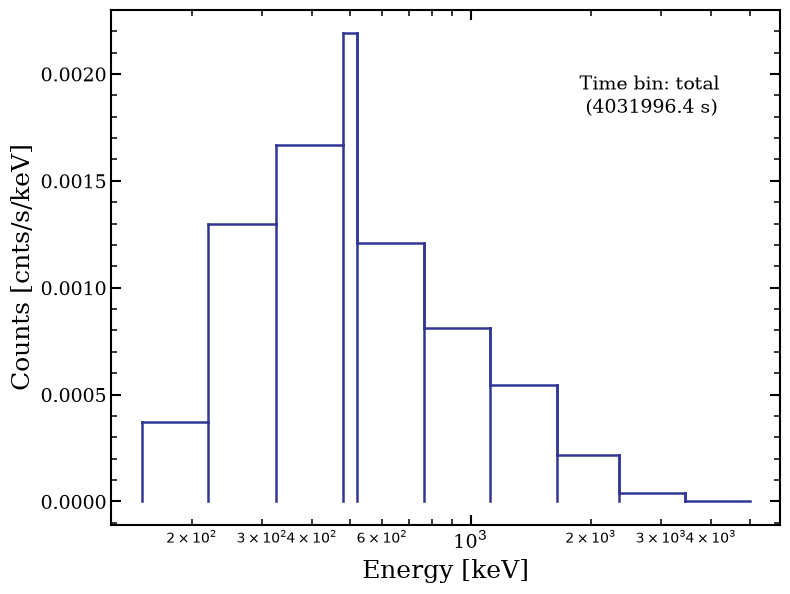

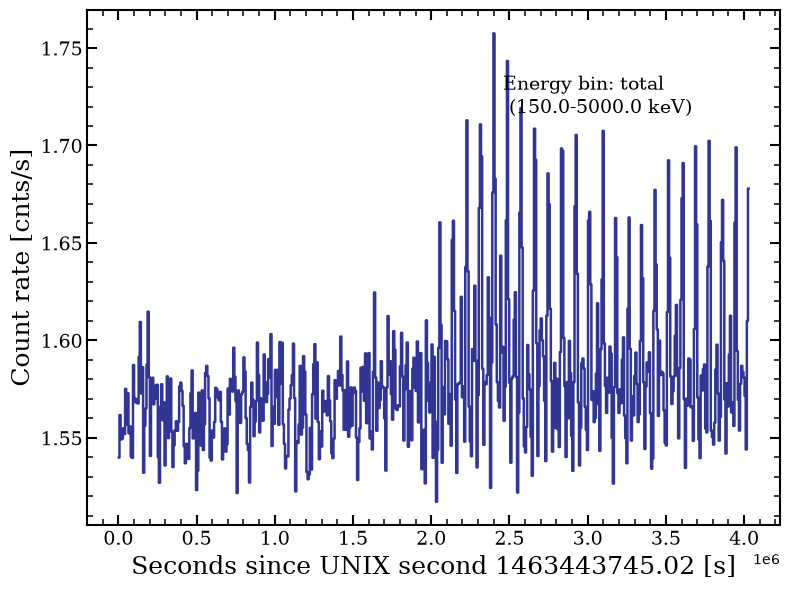

In [8]:
analysis_combined.dataset.plot_raw_spectrum()
plt.xscale('log')

analysis_combined.dataset.plot_lightcurve()

## Define the pointing object with the COSIpy pointing class.

The pointings refer to the direction/orientation of the telescope at each point in time. This cell usually takes a few minutes to run.

In [9]:
pointing_combined = Pointing(dataset=analysis_combined.dataset) # definition of pointings (balloon stability + Earth rotation)

## Visualize the paths of the Crab & Cen A through the field-of-view.

This isn't necessary for the spectral fitting, but is illustrative for understanding the pointings and exposure of the point sources.

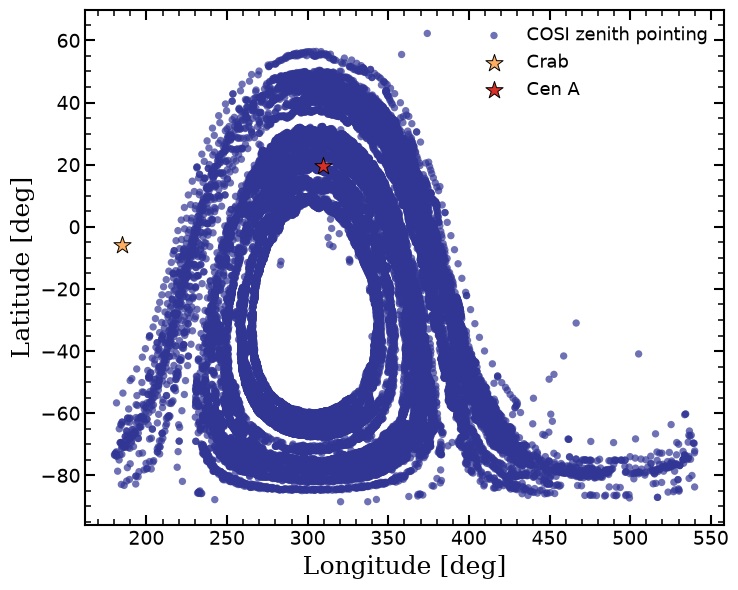

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 6))

ax.scatter(
    pointing_combined.zpoins[:, 0] + 360,
    pointing_combined.zpoins[:, 1],
    s=28,
    color="#313695",
    alpha=0.70,
    edgecolors="none",
    label="COSI zenith pointing",
)

ax.scatter(
    l_crab,
    b_crab,
    s=170,
    marker="*",
    color="#fdae61",
    edgecolors="black",
    linewidths=0.7,
    zorder=3,
    label="Crab",
)

ax.scatter(
    l_cenA,
    b_cenA,
    s=170,
    marker="*",
    color="#d73027",
    edgecolors="black",
    linewidths=0.7,
    zorder=3,
    label="Cen A",
)

ax.set_xlabel("Longitude [deg]", fontsize=18, fontfamily="serif")
ax.set_ylabel("Latitude [deg]", fontsize=18, fontfamily="serif")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.5)

ax.minorticks_on()
ax.tick_params(
    axis="both", which="major",
    direction="in", top=True, right=True,
    width=1.5, length=7, labelsize=14,
)
ax.tick_params(
    axis="both", which="minor",
    direction="in", top=True, right=True,
    width=1.1, length=4,
)

ax.legend(frameon=False, fontsize=13)
fig.tight_layout()

plt.show()

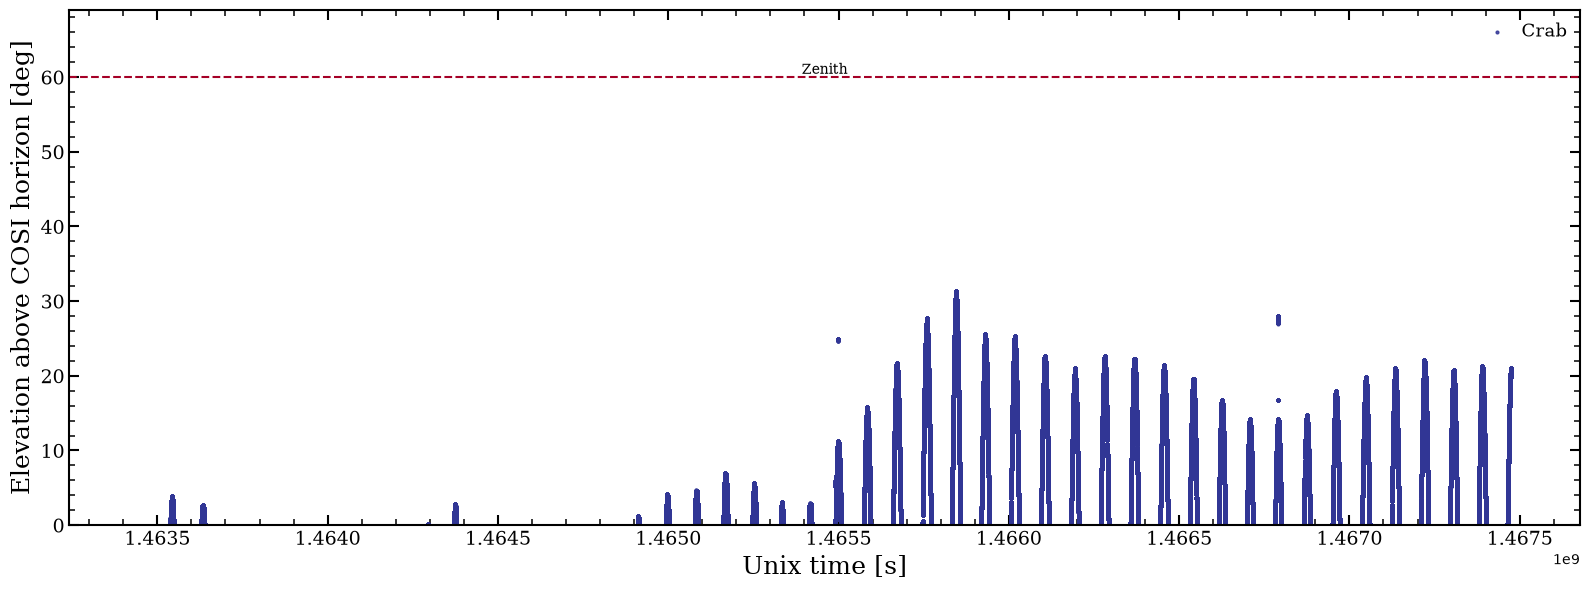

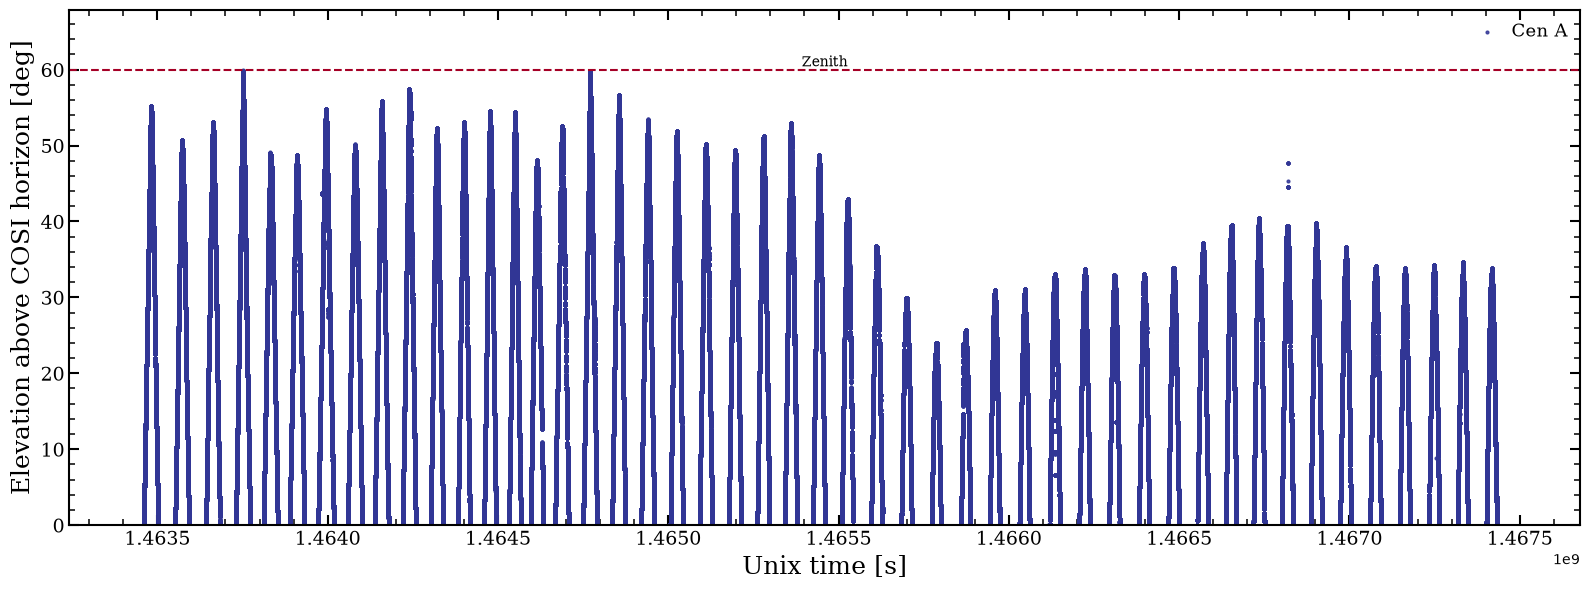

In [17]:
analysis_combined.plot_elevation([l_crab],[b_crab],['Crab'])

analysis_combined.plot_elevation([l_cenA],[b_cenA],['Cen A'])

# Define the BG model.

In [18]:
# Ling BG simulation to model atmospheric background
background_combined = BG(dataset=analysis_combined.dataset,mode=background_mode,filename=background_filename) # read in background

Using background mode: from file


# Read in the Response Matrix

This usually takes a few minutes.

In [19]:
# continuum response
rsp = response.SkyResponse(filename=response_filename,pixel_size=pixel_size) # read in detector response

Reading response.
Done.

Creating general RMF matrices.


Loop over phi bins::   0%|          | 0/30 [00:00<?, ?it/s]

Done.

Creating general IRF.
Done.

Deleting full matrix.
Done.


## Explore the shape of the data space.

The shape of the response spans (Galactic latitude $b$, Galactic longitude $\ell$, Compton scattering angle $\phi$, FISBEL, energy). The shape of the data and background objects span (time, energy, Compton scattering angle, FISBEL), as explained above.

In [20]:
print('Shape of response matrix (b, l, ϕ, FISBEL, energy):')
print(rsp.rsp.response_grid_normed_efinal.shape)
print()
print('Shape of binned data (time, energy, ϕ, FISBEL):')
print(analysis_combined.dataset.binned_data.shape)
print()
print('Shape of background model (time, energy, ϕ, FISBEL):')
print(np.shape(background_combined.bg_model))

Shape of response matrix (b, l, ϕ, FISBEL, energy):
(30, 60, 30, 1145, 10)

Shape of binned data (time, energy, ϕ, FISBEL):
(560, 10, 30, 1145)

Shape of background model (time, energy, ϕ, FISBEL):
(560, 10, 30, 1145)


# Calculate the point source response for the Crab.

In [21]:
rsp.calculate_PS_response(analysis_combined.dataset,pointing_combined,l_crab,b_crab,1,background=background_combined,pixel_size=pixel_size,lookup=False)

Loop over energy bins:   0%|          | 0/10 [00:00<?, ?it/s]

Loop over pointings::   0%|          | 0/45853 [00:00<?, ?it/s]

## Plot light curves for the data, background & sky models.

This is plotted for the 220-325 keV energy bin. The sky model is normalized to 1.

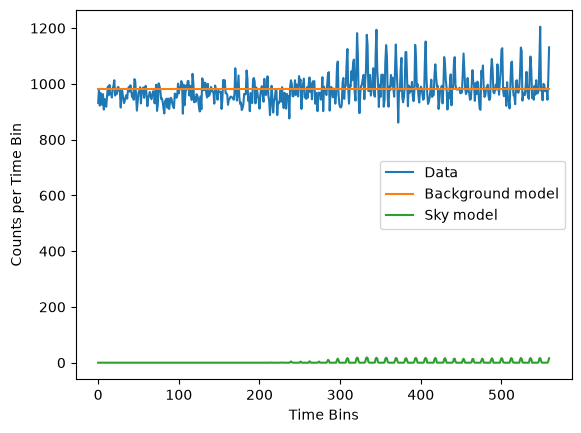

In [22]:
plt.plot(np.sum(analysis_combined.dataset.binned_data[:,1,:,:],axis=(1,2)), label="Data") # binned data light curve
plt.plot(np.sum(background_combined.bg_model_reduced[1],axis=1), label="Background model") # background model
plt.plot(np.sum(rsp.sky_response[1],axis=1)*1000, label="Sky model") # sky model
plt.xlabel('Time Bins')
plt.ylabel('Counts per Time Bin')
plt.legend()

# Extract the spectrum for the Crab.

For each energy bin individually, this determines the coefficients for the sky and background models that best match the data. It can take a few hours to run!

In [23]:
result_crab = fit(analysis_combined.dataset,pointing_combined,rsp,background_combined) # create fitting object
result_crab.fit(iters=2000) # perform spectral fit using emcee (uses pointing definition, background model, & point source response)

working on energy bin 0


100%|██████████| 2000/2000 [00:26<00:00, 76.88it/s]


working on energy bin 1


100%|██████████| 2000/2000 [00:55<00:00, 36.11it/s]


working on energy bin 2


...

100%|██████████| 2000/2000 [02:42<00:00, 12.33it/s]


working on energy bin 8


100%|██████████| 2000/2000 [02:41<00:00, 12.35it/s]


working on energy bin 9


100%|██████████| 2000/2000 [02:10<00:00, 15.35it/s]


## Plot the final count spectrum of the Crab.

Below is the spectrum (in counts/keV) of the Crab nebula!

The fitted value for the 480-520 keV bin is a bit low, which is likely due to the 511 keV line in the simulation.

The extracted spectrum data is saved as a .dat file.

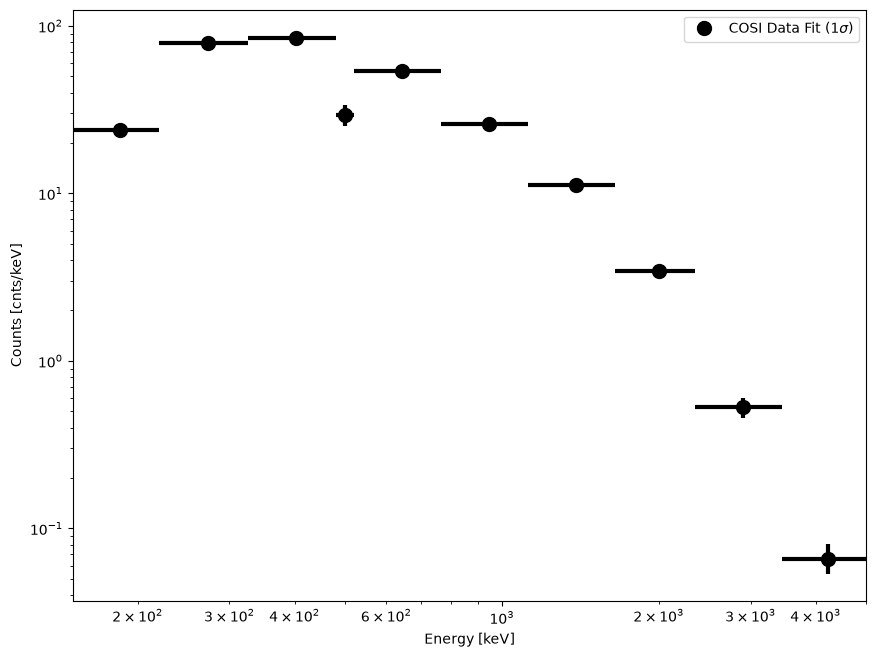

In [24]:
result_crab.plot_extracted_spectrum('crab_spectrum.dat')

# Analysis of Cen A

Now that we have successfully recovered the Crab spectrum from the full flight simulation, we will look at a slightly weaker source and discover some of the limitations with the current COSIpy classic implementation.

Since we’ve already loaded the COSI-balloon simulated data, response matrix and background model, we only need to redefine the point source sky model using Cen A’s coordinates and repeat the fit.

## Calculate the point source response for Cen A.

In [25]:
rsp.calculate_PS_response(analysis_combined.dataset,pointing_combined,l_cenA,b_cenA,1,background=background_combined,pixel_size=pixel_size,lookup=False)

Loop over energy bins:   0%|          | 0/10 [00:00<?, ?it/s]

Loop over pointings::   0%|          | 0/45853 [00:00<?, ?it/s]

## Extract the spectrum for Cen A.

This can take a few hours to run!

In [26]:
result_cenA = fit(analysis_combined.dataset,pointing_combined,rsp,background_combined) # create fitting object
result_cenA.fit(iters=2000) # perform spectral fit using emcee (uses pointing definition, background model, & point source response)

working on energy bin 0


100%|██████████| 2000/2000 [00:25<00:00, 77.33it/s]


working on energy bin 1


100%|██████████| 2000/2000 [00:56<00:00, 35.47it/s]


working on energy bin 2


...

100%|██████████| 2000/2000 [07:54<00:00,  4.22it/s]  


working on energy bin 8


100%|██████████| 2000/2000 [01:57<00:00, 17.01it/s]


working on energy bin 9


100%|██████████| 2000/2000 [02:06<00:00, 15.82it/s]


## Plot the spectrum of Cen A.

Below is the spectrum (in counts/keV) of the Cen A, with the extracted spectrum data saved as a .dat file.

The first plot includes error bars on each point, and the second shows upper limits where the signal-to-noise ratio (SNR) > 3.

The error bars for Cen A are very large, and almost all energy bins have upper limits. We believe this is due to the Crab's brightness interfering with the fit. To fix this, we need to include the Crab in the background model. Because the elevation of the Crab in COSI's field of view is changing over time, our background model would now be time-dependent. However, our current fitting algorithm only includes one background parameter, so we cannot handle a time-dependent background. Future versions of COSIpy will fix this issue.

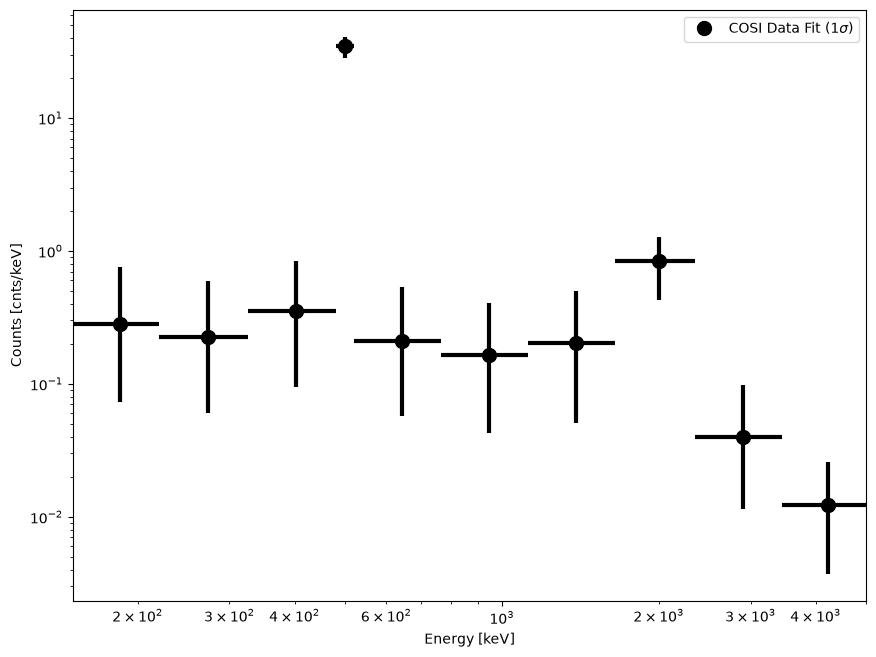

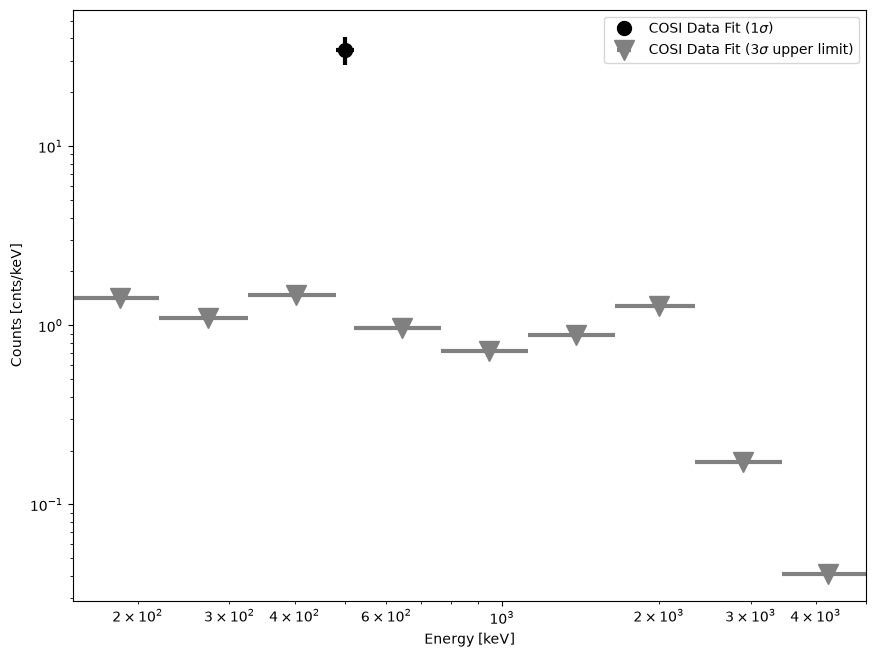

In [27]:
result_cenA.plot_extracted_spectrum('cenA_spectrum1.dat')
result_cenA.plot_extracted_spectrum('cenA_spectrum1.dat',ul=ul)

## Read in Cen A simulation and define analysis object.

To investigate why the fit is failing using the combined simulation, we will redo the Cen A analysis, but we will use a simulation that excludes the Crab and all other sources. The 'CenA_BG_10x.tra.gz' file includes only Cen A and the Ling background, and by repeating the above analysis, we will show that we can recover the Cen A count spectrum when the background model is static. For this analysis, we will only include the required cells. Please refer to the Crab analysis above for the details of each step.

This cell usually takes a few minutes to run.

In [28]:
analysis_cenA = COSIpy(data_dir,filename_cenA) # create analysis object
analysis_cenA.read_COSI_DataSet() # read in data

## Bin the data.

In [29]:
analysis_cenA.dataset.time_binning_tags(time_bin_size=Delta_T) # time binning
analysis_cenA.dataset.init_binning(energy_bin_edges=energy_bin_edges,pixel_size=pixel_size) # energy and pixel binning
analysis_cenA.dataset.get_binned_data() # bin data

## Define the pointing object.

This cell usually takes a few minutes to run

In [30]:
pointing_cenA = Pointing(dataset=analysis_cenA.dataset)

## Define the background model.

In [31]:
background_cenA = BG(dataset=analysis_cenA.dataset,mode=background_mode,filename=background_filename) # read in background

Using background mode: from file


## Calculate the point source response for Cen A.

In [32]:
rsp.calculate_PS_response(analysis_cenA.dataset,pointing_cenA,l_cenA,b_cenA,1,background=background_cenA,pixel_size=pixel_size,lookup=False)

Loop over energy bins:   0%|          | 0/10 [00:00<?, ?it/s]

Loop over pointings::   0%|          | 0/45844 [00:00<?, ?it/s]

## Plot light curves for data, background & sky models.

This is plotted for the 220-325 keV energy bin. The sky model is normalized to 1.

You can see that the data rates appear flatter here compared to the light curve above for the combined simulation. The Crab was mainly in COSI's field of view during the second half of the flight, and since we no longer have those additional counts, there is less variation in this light curve and sky model.

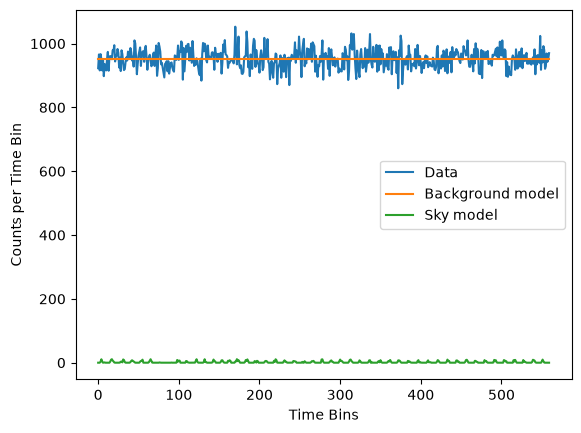

In [33]:
plt.plot(np.sum(analysis_cenA.dataset.binned_data[:,1,:,:],axis=(1,2)), label="Data") # binned data light curve
plt.plot(np.sum(background_cenA.bg_model_reduced[1],axis=1), label="Background model") # background model
plt.plot(np.sum(rsp.sky_response[1],axis=1)*1000, label="Sky model") # sky model
plt.xlabel('Time Bins')
plt.ylabel('Counts per Time Bin')
plt.legend()

## Extract the spectrum for Cen A.

This can take a few hours to run!

In [34]:
result_cenA2 = fit(analysis_cenA.dataset,pointing_cenA,rsp,background_cenA) # create fitting object
result_cenA2.fit(iters=2000) # perform spectral fit using emcee (uses pointing definition, background model, & point source response)

working on energy bin 0


100%|██████████| 2000/2000 [00:34<00:00, 58.17it/s]


working on energy bin 1


100%|██████████| 2000/2000 [01:13<00:00, 27.24it/s]


working on energy bin 2


...

100%|██████████| 2000/2000 [03:05<00:00, 10.79it/s]


working on energy bin 8


100%|██████████| 2000/2000 [03:06<00:00, 10.71it/s]


working on energy bin 9


100%|██████████| 2000/2000 [02:23<00:00, 13.96it/s]


## Plot the final count spectrum of Cen A.

Below is the spectrum (in counts/keV) of Centaurus A!

When we use a simulation of only Cen A and background, we are able to recover the correct spectrum. This emphasizes the need for more sophisticated background models which include time variability and bright sources, and this will be a focus for the next Data Challenge.

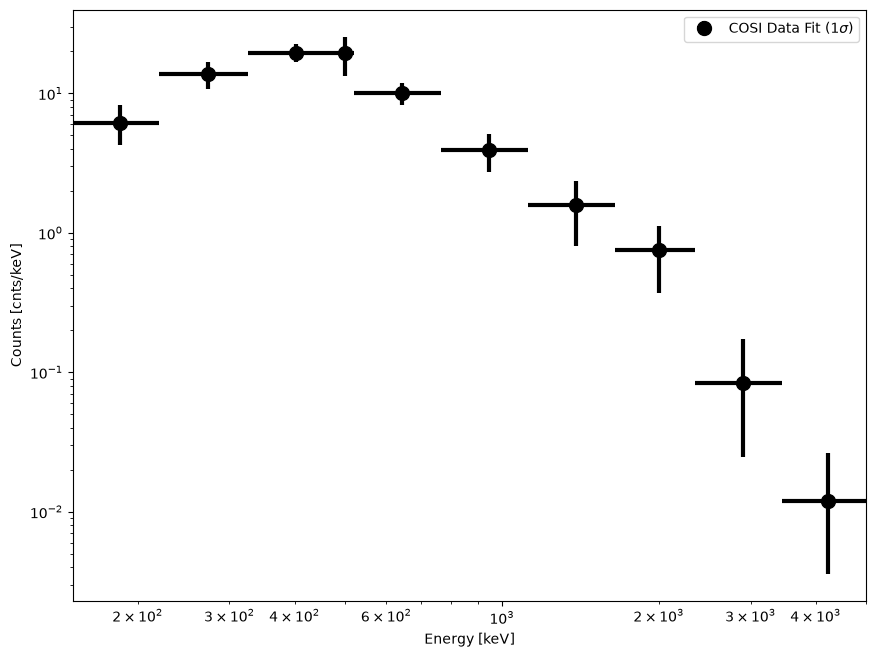

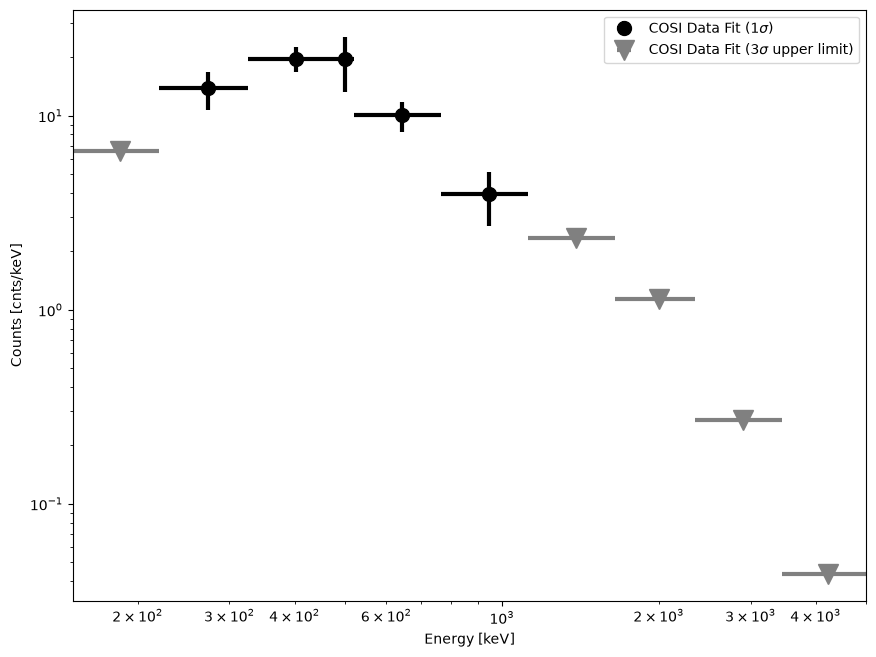

In [35]:
result_cenA2.plot_extracted_spectrum('cenA_only_spectrum1.dat')
result_cenA2.plot_extracted_spectrum('cenA_only_spectrum1.dat',ul=ul)